In [3]:
import os
os.chdir('/Users/lesymizz/groupproject_2')
import json
import pandas as pd # type: ignore
import re

In [4]:
files = {
    'artfact.products': 'groupproject_2/parsed/artfact.products.json',
    'geltekcosmetics': 'groupproject_2/parsed/geltekcosmetics.json',
    'mixit_ru': 'groupproject_2/parsed/mixit_ru.json',
    'iconskin': 'groupproject_2/parsed/iconskin.json',
    'wetty_lab': 'groupproject_2/parsed/wetty_lab.json',
    'theu_club': 'groupproject_2/parsed/theu_club.json',
    'open.face': 'groupproject_2/parsed/open.face.json',
    'librederm': 'groupproject_2/parsed/librederm.json',
    'aravia': 'groupproject_2/parsed/aravia.json',
    'naturasiberica_ru': 'groupproject_2/parsed/naturasiberica_ru.json',
    'vois': 'groupproject_2/parsed/vois.json',
    'lorealparisrussia': 'groupproject_2/parsed/lorealparisrussia.json',
    'beautybomb': 'groupproject_2/parsed/beautybomb.json',
}

total = 0

for brand, filename in files.items():
    with open(filename, "r", encoding="utf-8") as f:
        data = json.load(f)

    if 'response' in data:
        data = data['response']

    if 'items' not in data:
        print(f"{brand}: нет данных")
        continue

    count = len(data['items'])
    total += count
    print(f"{brand}: {count} постов")

print(f"\nВсего постов: {total}")

artfact.products: 104 постов
geltekcosmetics: 104 постов
mixit_ru: 104 постов
iconskin: 104 постов
wetty_lab: 104 постов
theu_club: 104 постов
open.face: 104 постов
librederm: 104 постов
aravia: 104 постов
naturasiberica_ru: 104 постов
vois: 104 постов
lorealparisrussia: 100 постов
beautybomb: 100 постов

Всего постов: 1344


оставим только те, где упоминается WB

In [5]:
files = {
    'artfact.products': 'groupproject_2/parsed/artfact.products_searched_wb.json',
    'geltekcosmetics': 'groupproject_2/parsed/geltekcosmetics_searched_wb.json',
    'mixit': 'groupproject_2/parsed/mixit_ru_searched_wb.json',
    'iconskin': 'groupproject_2/parsed/iconskin_searched_wb.json',
    'wetty_lab': 'groupproject_2/parsed/wetty_lab_searched_wb.json',
    'theu_club': 'groupproject_2/parsed/theu_club_searched_wb.json',
    'open.face': 'groupproject_2/parsed/open.face_searched_wb.json',
    'librederm': 'groupproject_2/parsed/librederm_searched_wb.json',
    'aravia': 'groupproject_2/parsed/aravia_searched_wb.json',
    'naturasiberica': 'groupproject_2/parsed/naturasiberica_searched_wb.json',
    'vois': 'groupproject_2/parsed/vois_searched_wb.json',
    'lorealparis': 'groupproject_2/parsed/lorealparis_searched_wb.json',
    'beautybomb': 'groupproject_2/parsed/beautybomb_searched_wb.json',
}

all_posts = []

for brand, filename in files.items():
    with open(filename, "r", encoding="utf-8") as f:
        data = json.load(f)

    # если есть обертка response снимаем ее, чтоб все json были однойц структуры(тк в разное время парсим, есть различия)
    if 'response' in data:
        data = data['response']


    if 'error' in data:
        print(f"{brand}: ОШИБКА — {data['error'].get('error_msg', 'нет данных')}")
        continue

    if 'items' not in data:
        print(f"{brand}: нет ключа items, пропускаем")
        continue

    posts = data['items']
    for post in posts:
        post['brand'] = brand
        all_posts.append(post)

    print(f"{brand}: {len(posts)} постов")

df = pd.DataFrame(all_posts)
print(f"\nВсего постов: {len(df)}")
df.to_csv("groupproject_2/vk_eda/all_searched_wb.csv", index=False, encoding="utf-8")

artfact.products: 100 постов
geltekcosmetics: 63 постов
mixit: 20 постов
iconskin: 13 постов
wetty_lab: 83 постов
theu_club: 48 постов
open.face: 0 постов
librederm: 3 постов
aravia: 72 постов
naturasiberica: ОШИБКА — User was deleted or banned
vois: 100 постов
lorealparis: 0 постов
beautybomb: 28 постов

Всего постов: 530


Напишем регулярные выражения при помощи которых будем проверять текст поста на наличие артикула(из данных полученных по вб знаем что в артикулах товаров которые мы получили может быть 7, 8 или 9 цифр подряд - это будем считать артикулом), а также будем если артикул не нашелся смотреть на следующее слово за WB - это предаоложительно ссылка либо на сайт-прослойку либо сразу на карточку товара, но у разных пабликов оформление может быть как со знаками препинания после WB, так и без них, будем учитывать это при проверке(нас интересует следующее непробелное слово после спецсимволов), после этого проверяем что слово похоже на ссылку

мы не можем просто брать все ссылки, тк там ссылки ведут и на личные сайты магазинов и на другие маркетплейсы, оттуда нельзя извлечь артикул. А убрать эту проверку тоже нельзя, тк иногда WB упоминается в контексте промокодов на скидки или рекламы

In [6]:
df = pd.read_csv("groupproject_2/vk_eda/all_searched_wb.csv")

article_pattern = r'\b\d{7,9}\b'
word_after_wb_pattern = r'WB\W*(\S+)'
link_pattern = r'(http|www|\.ru|\.com|\.by|\.kz|vk\.cc|clck|\.ly)'

def find_article_or_link(text):
    if pd.isna(text):
        return None

    article = re.search(article_pattern, text)
    if article:
        return article.group(0)

    word = re.search(word_after_wb_pattern, text)
    if word:
        candidate = word.group(1)
        # проверяем что это похоже на ссылку
        if re.search(link_pattern, candidate):
            return candidate

    return None

df['article_or_link'] = df['text'].apply(find_article_or_link)

print(f"Всего постов: {len(df)}")
print(f"Содержат артикул или ссылку: {df['article_or_link'].notna().sum()}")

df.to_csv("groupproject_2/vk_eda/all_searched_wb_with_articles.csv", index=False, encoding="utf-8")

Всего постов: 530
Содержат артикул или ссылку: 249


проверим вручную, скорее всего что-то не учли и есть больше ссылок

In [7]:
not_found = df[df['article_or_link'].isna()]
found = df[df['article_or_link'].notna()]

for i, row in not_found.iterrows():
    print(row['text'])

for i, row in found.iterrows():
    print(f"найдено {row['article_or_link']}")
    print(row['text'])

Запускаем бьюти-монополию! 🎲

Помнишь, как в детстве с азартом бросали кубик, покупали улицы и строили отели в Монополии? Мы решили подарить те же эмоции, но теперь – с возможностью выиграть не просто игру, а крутой уход за кожей!

До 30 апреля сыграй в нашу бьюти-монополию «Поле фактов» на Ozon, WB и Яндекс.Маркете и получи скидку 20% на средства.*

💡Как играть?
- Выбери «улицу» под запрос твоей кожи (glow-up, анти-акне, увлажнение и т. д.).
- Добавь продукты из подборки в корзину.
- Примени промокод:
  - AFPOLE20 – для Ozon и WB.
  - POLEAF20 – для Яндекс.Маркета.

🎁 Победа — это полноценный уход со скидкой!

*Акция действует только на товары бренда, представленные в игре.

OZON ([#alias|clc.to/QP-Tdw|https://clc.to/QP-Tdw]) | WB ([#alias|clc.to/wPCPeA|https://clc.to/wPCPeA]) | ЯМ ([#alias|clc.to/62mO2g|https://clc.to/62mO2g])

Удачной игры ❤️
nan
nan
Эта новинка с нотками ностальгии точно придётся тебе по душе.
⠀
Объединили рабочую формулу и вкус воспоминаний — знакомься, первая энз

Добавим умение распознавать такую конструкцию которая встретилась и мы ее не распознали как нужную([#alias|...|ссылка]) в регулярку 

In [8]:
article_pattern = r'\b\d{7,9}\b'
alias_pattern = r'WB[^\w]*\[#alias\|[^|]*\|([^\]]+)\]'
word_after_wb_pattern = r'WB\W*(\S+)'
link_pattern = r'(http|www|\.ru|\.com|\.by|\.kz|vk\.cc|clck|clc\.to|\.ly)'

def find_article_or_link(text):
    if pd.isna(text):
        return None
    article = re.search(article_pattern, text)
    if article:
        return article.group(0)
    alias = re.search(alias_pattern, text)
    if alias:
        return alias.group(1)
    word = re.search(word_after_wb_pattern, text)
    if word:
        candidate = word.group(1)
        if re.search(link_pattern, candidate):
            return candidate

    return None

df['article_or_link'] = df['text'].apply(find_article_or_link)

print(f"Всего постов: {len(df)}")
print(f"Содержат артикул или ссылку: {df['article_or_link'].notna().sum()}")

df.to_csv("groupproject_2/vk_eda/all_searched_wb_with_articles.csv", index=False, encoding="utf-8")

Всего постов: 530
Содержат артикул или ссылку: 252


ну стало немного лучше, но поищем еще

In [9]:
pd.set_option('display.max_colwidth', None)
not_found = df[df['article_or_link'].isna()]

for i, row in not_found.iterrows():
    print(f"бренд {row['brand']}")
    print(row['text'])

бренд artfact.products
nan
бренд artfact.products
nan
бренд artfact.products
Эта новинка с нотками ностальгии точно придётся тебе по душе.
⠀
Объединили рабочую формулу и вкус воспоминаний — знакомься, первая энзимная пудра [club191623389|ART&FACT.] с ароматом малины.
⠀
Запах сочной ягоды уносит в беззаботное детство у бабушки — туда, где утро начинается с горсти малины с грядки и продолжается свежими пирогами на подоконнике 💔

Соединили в новинке не только приятный аромат, но и эффективность.

Энзимная пудра 5 в 1 глубоко очищает, придаёт коже сияние, регулирует жирность, успокаивает и подходит как для тела, так и головы.

Пенка для умывания, пилинг, скраб для тела, средство против вросших волос или эксфолиант для головы — экспериментируй, эта баночка подстроится под твои потребности.

👉🏻 Пудра будет доступна на Ozon и WB уже совсем скоро.

А первыми выгодно заказать новинку смогут те, кто внимательно следит за нашими новостями!
⠀
‼️ Ставь уведомления, чтобы не пропустить старт продаж!

Видны категории постов:
1.посты типа "На WB", "Wb", "кинула в корзину на WB", комментарии пользователей. Там реально нет ни артикула, ни ссылки на товар, нас такие не интересуют и правильно что мы их отсеяли
2.пропущенные ссылки на вб/сайт-прослойку, но которые идут не сразу после WB, а со смайлом или еще словом (WB: 30 мл ([#alias|vk.cc/cKRE3L|...]) после "WB" идёт размер, а потом alias  WB:\nМолочко ([#alias|vk.cc/...|...]))
3.или даже список, где WB это заголовок, а ссылки ниже построчно
(Купить на WB — [#alias|www.wildberries.ru/...|https://...] тире вместо двоеточия
WB 👉🏼 [#alias|vois.mobz.click/...|https://...] эмодзи между WB и ссылкой)

Добавим их в наше регулярное выражение( ищем WB и в пределах 500 символов (до переноса строки или конца) alias-ссылка и [^\n] чтобы не выходить за пределы одной строки (чтобы не взять случайно ссылку от другого маркетплейса как нужную))


In [10]:
# артикул на той же строке с WB и рядом с WB, чтоб не спутать с артикулом на OZON (до 50 символов)
article_near_wb_pattern = r'(?:WB[^\n]{0,50}?\b(\d{7,9})\b|\b(\d{7,9})\b[^\n]{0,50}?WB)'

# http-ссылка на той же строке с WB
link_after_wb_pattern = r'WB[^\n]{0,100}?(https?://\S+|vk\.cc/\S+|clc\.to/\S+|vois\.mobz\.click/\S+)'

# прямая ссылка на wildberries.ru где угодно в тексте
wb_direct_link_pattern = r'(https?://[^\s\]\)]*wildberries\.ru[^\s\]\)]*)'

# alias-ссылка где угодно в тексте, если в тексте упоминается WB
any_alias_if_wb_pattern = r'\[#alias\|[^|]*\|([^\]]+)\]'

#слово после WB, похожее на ссылку
word_after_wb_pattern = r'WB\W*(\S+)'
link_pattern = r'(http|www|\.ru|\.com|vk\.cc|clc\.to|mobz\.click)'

def find_article_or_link(text):
    if pd.isna(text):
        return None

    article = re.search(article_pattern, text)
    if article:
        return article.group(0)

    link = re.search(link_after_wb_pattern, text)
    if link:
        return link.group(1)

    wb_link = re.search(wb_direct_link_pattern, text)
    if wb_link:
        return wb_link.group(1)

    if re.search(r'\bWB\b|\bWb\b|\bwb\b', text):
        any_alias = re.search(any_alias_if_wb_pattern, text)
        if any_alias:
            return any_alias.group(1)

    word = re.search(word_after_wb_pattern, text)
    if word:
        candidate = word.group(1)
        if re.search(link_pattern, candidate):
            return candidate

    return None

df['article_or_link'] = df['text'].apply(find_article_or_link)

print(f"Всего постов: {len(df)}")
print(f"Содержат артикул или ссылку: {df['article_or_link'].notna().sum()}")

df.to_csv("groupproject_2/vk_eda/all_searched_wb_with_articles.csv", index=False, encoding="utf-8")
print("Сохранено")

Всего постов: 530
Содержат артикул или ссылку: 292
Сохранено


In [11]:
dt = pd.read_csv("groupproject_2/vk_eda/all_searched_wb_with_articles.csv")
pd.set_option('display.max_colwidth', None)
not_found = dt[dt['article_or_link'].isna()]

for i, row in not_found.iterrows():
    print(f"бренд {row['brand']}")
    print(row['text'])

бренд artfact.products
nan
бренд artfact.products
nan
бренд artfact.products
Эта новинка с нотками ностальгии точно придётся тебе по душе.
⠀
Объединили рабочую формулу и вкус воспоминаний — знакомься, первая энзимная пудра [club191623389|ART&FACT.] с ароматом малины.
⠀
Запах сочной ягоды уносит в беззаботное детство у бабушки — туда, где утро начинается с горсти малины с грядки и продолжается свежими пирогами на подоконнике 💔

Соединили в новинке не только приятный аромат, но и эффективность.

Энзимная пудра 5 в 1 глубоко очищает, придаёт коже сияние, регулирует жирность, успокаивает и подходит как для тела, так и головы.

Пенка для умывания, пилинг, скраб для тела, средство против вросших волос или эксфолиант для головы — экспериментируй, эта баночка подстроится под твои потребности.

👉🏻 Пудра будет доступна на Ozon и WB уже совсем скоро.

А первыми выгодно заказать новинку смогут те, кто внимательно следит за нашими новостями!
⠀
‼️ Ставь уведомления, чтобы не пропустить старт продаж!

Получилось, что выловили все, что может привести нас к артикулу на товар вб, остались только комментарии пользователей с вопросами про вб, они как интерес к продукту будут учтены в комментариях к посту, так что их можно не рассматривать в дальнейшем исследовании

категоризируем полученные результаты, c сылками нужно бцдет еще раз проделать извлечение данных с вб, чтобы получить артикулы и далее связать с датасетом по вб

In [13]:
found = df[df['article_or_link'].notna()].copy()

def classify(value):
    value = str(value)
    if re.fullmatch(r'\d{7,9}', value):
        return 'артикул'
    if 'wildberries.ru' in value or 'vk.cc' in value or 'clc.to' in value:
        return 'ссылка на WB'
    return 'ссылка-прослойка'

found['тип'] = found['article_or_link'].apply(classify)

print(found['тип'].value_counts())

wb_links = found[found['тип'] == 'ссылка на WB']
proxy_links = found[found['тип'] == 'ссылка-прослойка']
articles = found[found['тип'] == 'артикул']

wb_links.to_csv("groupproject_2/vk_eda/wb_links.csv", index=False, encoding="utf-8")
proxy_links.to_csv("groupproject_2/vk_eda/proxy_links.csv", index=False, encoding="utf-8")
articles.to_csv("groupproject_2/vk_eda/articles.csv", index=False, encoding="utf-8")

тип
артикул             123
ссылка-прослойка     98
ссылка на WB         71
Name: count, dtype: int64


чищу ссылки

In [14]:
def clean_link(link):
    if pd.isna(link):
        return link
    link = str(link).strip()
    if '|' in link:
        link = link.split('|')[-1]
    link = link.rstrip('])., ')
    if not link.startswith('http'):
        link = 'https://' + link
    return link

for filename in ["groupproject_2/vk_eda/wb_links.csv", "groupproject_2/vk_eda/proxy_links.csv"]:
    df = pd.read_csv(filename)
    df['article_or_link'] = df['article_or_link'].apply(clean_link)
    df.to_csv(filename, index=False, encoding="utf-8")
    print(df['article_or_link'].head(10).tolist())
    print()

['https://clc.to/wPCPeA', 'https://clc.to/SpQOHQ', 'https://vk.cc/cW35g2', 'https://vk.cc/cVU14O', 'https://vk.cc/cVOzit', 'https://vk.cc/cVMDzr', 'https://vk.cc/cVJ7wV', 'https://vk.cc/cVx1B4', 'https://vk.cc/cVrjzB', 'https://vk.cc/cVnkS4']

['https://clck.ru/3S9wsd', 'https://clck.ru/3S7gZQ', 'https://clck.ru/3Rq2Ps', 'https://clck.ru/3Rm42Q', 'https://clck.ru/3Riew8', 'https://clck.ru/3RhVNd', 'https://clck.ru/3ReA94', 'https://clck.ru/3RZhB3', 'https://clck.ru/3RXC39', 'https://clck.ru/3RX35Z']



Напишем wb_links_parser.py для ссылок, которые уже ведут на WB (vk.cc, clc.to, прямые wildberries.ru). Эти ссылки сами редиректят на нужный товар и парсеру достаточно зайти и посмотреть итоговую ссылку,

proxy_links_parser.py для прослоек (mobz.click и тд.), там может не быть автоматического редиректа, поэтому если после захода url не содержит wb, скрипт пытается найти и кликнуть кнопку с текстом перейти, открыть или с href на wb

парсер открывает ссылки-прослойки через Selenium, у некоторых из них есть clck.ru (сокращалка Яндекса) и вместо редиректа на wildberries появляется капча, и скрипт не может извлечь артикул.
Добавим проверку что если после открытия ссылки есть showcaptcha, скрипт ставит паузу через input() и ждёт Enter. Яндекс после одного успешного прохождения капчи помечает браузер как доверенный, и следующие ссылки открываются уже без неё. Автоматический обход капчи делать не будем тк это нарушает условия использования сервиса и технически сложно

обьединим итоговый файл с артикулами и информацией об упоминании товара в посте вк

In [30]:
wb = pd.read_csv("groupproject_2/vk_eda/wb_links_articles.csv")
proxy = pd.read_csv("groupproject_2/vk_eda/proxy_links_articles.csv")
articles = pd.read_csv("groupproject_2/vk_eda/articles.csv")

articles['final_url'] = ''
articles['article'] = articles['article_or_link']

print("wb_links_articles:", wb.shape)
print("proxy_links_articles:", proxy.shape)
print("articles:", articles.shape)

all_posts = pd.concat([wb, proxy, articles], ignore_index=True)

print("\nобъединённый:", all_posts.shape)

all_posts.to_csv("groupproject_2/vk_eda/all_posts_with_articles.csv", index=False, encoding="utf-8")

wb_links_articles: (71, 35)
proxy_links_articles: (98, 35)
articles: (123, 35)

объединённый: (292, 35)


In [31]:
import numpy as np # type: ignore
import seaborn as sns # type: ignore
import matplotlib.pyplot as plt # type: ignore
import ast
from IPython.core.pylabtools import figsize # type: ignore

In [32]:
data = pd.read_csv('groupproject_2/vk_eda/all_posts_with_articles.csv')

def safe_parse(value):
    if pd.isna(value):
        return {}
    try:
        return ast.literal_eval(value)
    except Exception:
        return {}

data['comments_count'] = data['comments'].apply(lambda x: safe_parse(x).get('count', 0))
data['likes_count'] = data['likes'].apply(lambda x: safe_parse(x).get('count', 0))
data['reposts_count'] = data['reposts'].apply(lambda x: safe_parse(x).get('count', 0))
data['views_count'] = data['views'].apply(lambda x: safe_parse(x).get('count', 0))

data['date'] = pd.to_datetime(data['date'], unit='s')

columns_to_keep = [
    'brand', 'date', 'text',
    'likes_count', 'comments_count', 'reposts_count', 'views_count',
    'article_or_link', 'final_url', 'article', 'тип'
]
columns_to_keep = [c for c in columns_to_keep if c in data.columns]
data = data[columns_to_keep]

data.to_csv('groupproject_2/vk_eda/all_posts_clean.csv', index=False, encoding='utf-8')

print(data.shape)
data.head()

(292, 11)


,brand,date,text,likes_count,comments_count,reposts_count,views_count,article_or_link,final_url,article,тип
0,artfact.products,2026-04-06 14:55:59,"Запускаем бьюти-монополию! 🎲\n\nПомнишь, как в детстве с азартом бросали кубик, покупали улицы и строили отели в Монополии? Мы решили подарить те же эмоции, но теперь – с возможностью выиграть не просто игру, а крутой уход за кожей!\n\nДо 30 апреля сыграй в нашу бьюти-монополию «Поле фактов» на Ozon, WB и Яндекс.Маркете и получи скидку 20% на средства.*\n\n💡Как играть?\n- Выбери «улицу» под запрос твоей кожи (glow-up, анти-акне, увлажнение и т. д.).\n- Добавь продукты из подборки в корзину.\n- Примени промокод:\n - AFPOLE20 – для Ozon и WB.\n - POLEAF20 – для Яндекс.Маркета.\n\n🎁 Победа — это полноценный уход со скидкой!\n\n*Акция действует только на товары бренда, представленные в игре.\n\nOZON ([#alias|clc.to/QP-Tdw|https://clc.to/QP-Tdw]) | WB ([#alias|clc.to/wPCPeA|https://clc.to/wPCPeA]) | ЯМ ([#alias|clc.to/62mO2g|https://clc.to/62mO2g])\n\nУдачной игры ❤️",17,0,0,643,https://clc.to/wPCPeA,https://www.wildberries.ru/brands/art-and-fact,NaN,ссылка на WB
1,artfact.products,2026-04-02 14:38:36,"Первое апреля прошло, а, значит, это точно не шутка! \nМы запускаем новую категорию средств😍\n\nДа, ты всё правильно поняла: к сезону «голых ног» мы разработали не типичную для нас новинку — мусс-автозагар с уходовыми компонентами в составе. Все, как мы любим!\n\nОн не только придает коже ровный красивый оттенок, но и заботится о ней, делая загар мягким и сияющим, а кожу гладкой и увлажненной.\n\nА ещё мусс ну очень приятно пахнет и доступен в двух оттенках, чтобы ты смогла подобрать идеальный тон.\n\nВ чём секрет? Рассказали в карточках ✨\n\nСветлый - WB ([#alias|clc.to/SpQOHQ|https://clc.to/SpQOHQ]) | OZON ([#alias|clc.to/7vgjiQ|https://clc.to/7vgjiQ]) \nТемный - WB ([#alias|clc.to/s94FSA|https://clc.to/s94FSA]) | OZON ([#alias|clc.to/fSu0LA|https://clc.to/fSu0LA])\n\nА до 7 апреля дарим промокод AFZAGAR, который даст скидку на 50% на WB и OZON!",24,2,0,1025,https://clc.to/SpQOHQ,https://www.wildberries.ru/catalog/884634860/detail.aspx?utm_source=vk&utm_medium=smm&utm_campaign=285068-id-smm_vk_artfact_4638_02-04-2026,884634860.0,ссылка на WB
2,artfact.products,2026-03-31 09:00:21,"Когда продукт становится не просто баночкой в ванной, а поводом для искреннего разговора🤍\n\nПять инфлюенсеров и друзей бренда попробовали маску «К себе нежно», и каждый поделился своими ритуалами заботы. Ведь речь не просто о средстве, а о моменте, когда удалось выдохнуть и побыть наедине с собой.\n\nWB ([#alias|vk.cc/cW35g2|https://vk.cc/cW35g2]) | OZON ([#alias|vk.cc/cW35dc|https://vk.cc/cW35dc]) \n\nЛистай и делись своими советами🌸",40,3,0,1000,https://vk.cc/cW35g2,https://www.wildberries.ru/catalog/760104825/detail.aspx?utm_source=vk&utm_medium=smm&utm_campaign=285068-id-smm_vk_artfact_4635_31-03-2026,760104825.0,ссылка на WB
3,artfact.products,2026-03-26 12:28:16,"Да кто такие эти ваши микроиглы? Без паники — сейчас всё расскажем! 😌\n\nМы создали новый классный продукт — маску со спикулами. \n\nСпикулы — это микроскопические иглы природного происхождения, которые мягко воздействуют на кожу, создавая микро-каналы и помогая ингредиентам проникать глубже.\n\nВ основе маски настоящий коктейль силы:\n\n🤍 Ниацинамид + Арбутин + Транексамовая кислота + Троксерутин.\nВместе они творят чудеса — выравнивают тон, осветляют пигментацию и дарят коже здоровое сияние. \n\nWB ([#alias|vk.cc/cVU14O|https://vk.cc/cVU14O]) | OZON ([#alias|vk.cc/cVU12E|https://vk.cc/cVU12E])\n\nКак? Рассказали в карточках! 💜\n\nА до 1 апреля дарим тебе промокод spikuly15, который даст скидку 15% на OZON.",53,4,0,1014,https://vk.cc/cVU14O,https://www.wildberries.ru/catalog/807378841/detail.aspx?utm_source=vk&utm_medium=smm&utm_campaign=285068-id-smm_vk_artfact_4633_26-03-2026,807378841.0,ссылка на WB
4,artfact.products,2026-03-24 09:00:09,"У тебя тоже бывает так: стоишь перед зеркалом с чистой головой, а она как будто вообще и не чистая?…\n\

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   brand            292 non-null    object        
 1   date             292 non-null    datetime64[ns]
 2   text             292 non-null    object        
 3   likes_count      292 non-null    int64         
 4   comments_count   292 non-null    int64         
 5   reposts_count    292 non-null    int64         
 6   views_count      292 non-null    int64         
 7   article_or_link  292 non-null    object        
 8   final_url        169 non-null    object        
 9   article          256 non-null    float64       
 10  тип              292 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 25.2+ KB


In [36]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = df.isnull().sum() / len(df)

    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

    mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})

    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)

    print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
        "There are " + str(mis_val_table_ren_columns.shape[0]) +
            " columns that have missing values.")

    return mis_val_table_ren_columns

In [37]:
data.isna().sum()

brand                0
date                 0
text                 0
likes_count          0
comments_count       0
reposts_count        0
views_count          0
article_or_link      0
final_url          123
article             36
тип                  0
dtype: int64

видим что пропуски есть в final_url - это поле куда добавлялась очищенная ссылка из которой нужно достать артикул, поэтому для постов где изначально достали артикул, поле осталосб пустым

поле article (артикул) осталось пустым для тех постов где ссылка вела на бренд вб, а не на конкретный товар, эти посты нас не интересуют, тк по ним вывод сделать не получится

Итого необходимо удалить записи где пропуски по артикулу

In [38]:
data = data.dropna(subset=['article'])
data.shape

(256, 11)

посмотрим на наличие каких-то странностей в датасете

In [ ]:
print("отрицательные лайки:", (data['likes_count'] < 0).sum())
print("отрицательные просмотры:", (data['views_count'] < 0).sum())
print("лайков больше чем просмотров:", (data['likes_count'] > data['views_count']).sum())
print("посты с нулевыми просмотрами:", (data['views_count'] == 0).sum())
print("посты из будущего:", (data['date'] > pd.Timestamp.now()).sum())


отрицательные лайки: 0
отрицательные просмотры: 0
лайков больше чем просмотров: 6
посты с нулевыми просмотрами: 14
посты из будущего: 0


там где лайков больше чем просмотров (6 постов) -это баг VK API или исторический артефакт. метрика views появилась в VK только в 2017 году, и для старых постов она просто равна 0 или не трекается, при этом лайки на них копятся до сих пор
еще бывает что views считает только уникальных зрителей, а лайки могут оставлять и те кто видел пост через репост в другом паблике - они технически они не попали в views оригинала но лайк оставили

для нашей задачи (связь упоминаний в VK с продажами на WB) эти посты считаем мусором, тк невозможно корректно посчитать вовлеченность

In [77]:
data = data[data['views_count'] >= data['likes_count']]

там где посты с нулевыми просмотрами (14 постов) могло произойти из-за свежих посты которые только опубликованы и views еще не успели подтянуться (но у нас таких быть не должно тк мы парсили уже существующие данные)
это не полностью мусор, тк пост реально существовал, лайки там настоящие, но для анализа вовлеченности эти посты сломают формулу, оставим их, но в метрике вовлеченности они роли не играют

Text(0.5, 1.0, 'Связь лайков и просмотров на постах ВК')

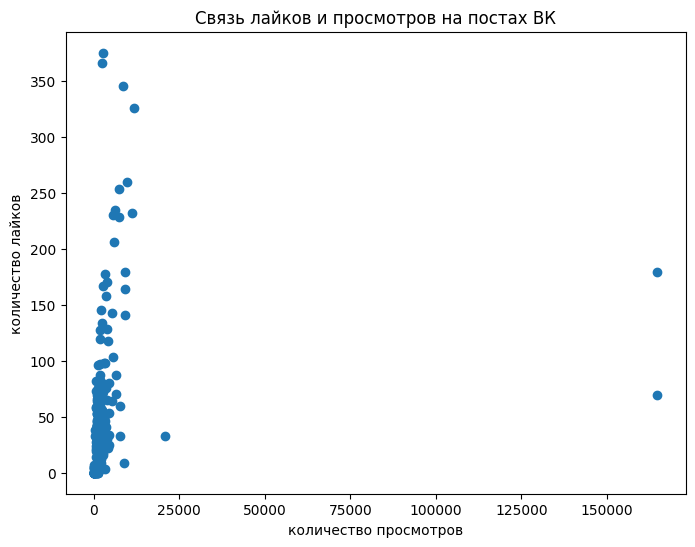

In [96]:
figsize(8, 6)

plt.scatter(data['views_count'], data['likes_count'])

plt.xlabel('количество просмотров')
plt.ylabel('количество лайков')
plt.title('Связь лайков и просмотров на постах ВК')

не видим прямой сильной зависимости количсетва просмотров и количества лайков, значит количества лайков возможно зависит от того насколько поллзователям нравится тот или другой конкретный бренд

выбросы есть, но это органические данные, тк бренды возможно закупали рекламу и тд, оставляем

Text(0.5, 1.0, 'Распределение количества лайков по брендам ВК')

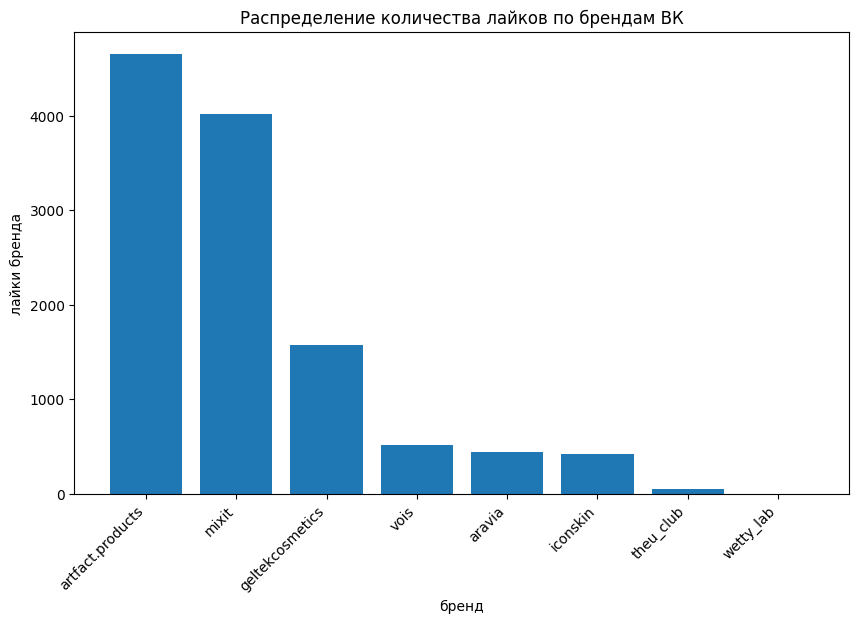

In [97]:
figsize(10, 6)

brand_likes = data.groupby('brand')['likes_count'].sum().sort_values(ascending=False)
plt.bar(brand_likes.index, brand_likes.values)
plt.xticks(rotation = 45, ha = 'right')
plt.xlabel('бренд')
plt.ylabel('лайки бренда')
plt.title('Распределение количества лайков по брендам ВК')

artfact.products и mixit сильно впереди по сумме лайков, при этом у mixit постов меньше в 1.5 раза значит лайки там собираются активнее на пост. geltekcosmetics на третьем месте но отрыв большой, остальные бренды почти не получают реакций

Text(0.5, 1.0, 'Распределение количества просмотров по брендам ВК')

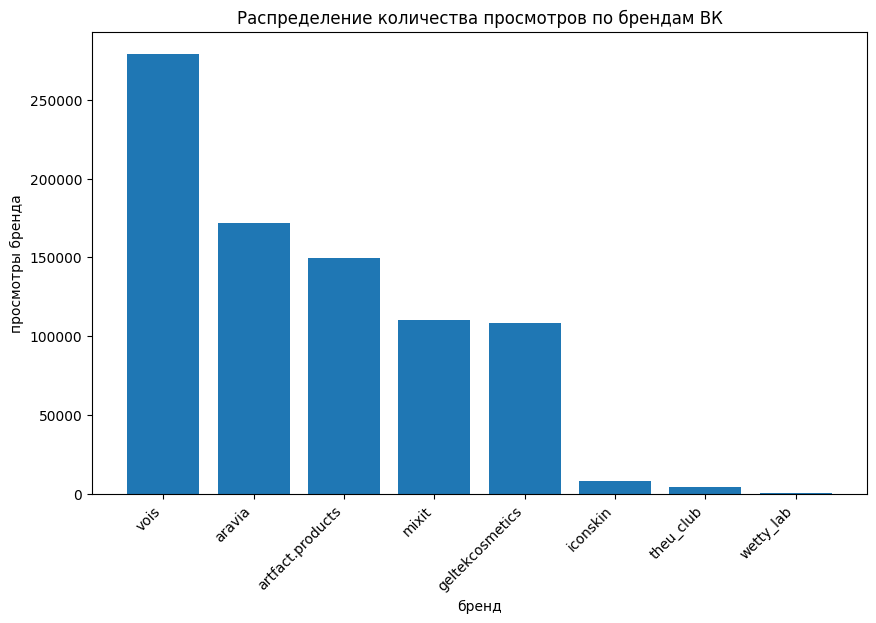

In [98]:
figsize(10, 6)

brand_views = data.groupby('brand')['views_count'].sum().sort_values(ascending=False)
plt.bar(brand_views.index, brand_views.values)
plt.xticks(rotation = 45, ha = 'right')
plt.xlabel('бренд')
plt.ylabel('просмотры бренда')
plt.title('Распределение количества просмотров по брендам ВК')

картина совсем другая тк по просмотрам лидирует vois хотя по лайкам он был почти в самом конце. aravia тоже выстреливает по просмотрам но лайков почти нет. значит у этих брендов большой охват но низкая вовлеченность, посты видят но не реагируют

Text(0.5, 1.0, 'Распределение количества постов по брендам ВК')

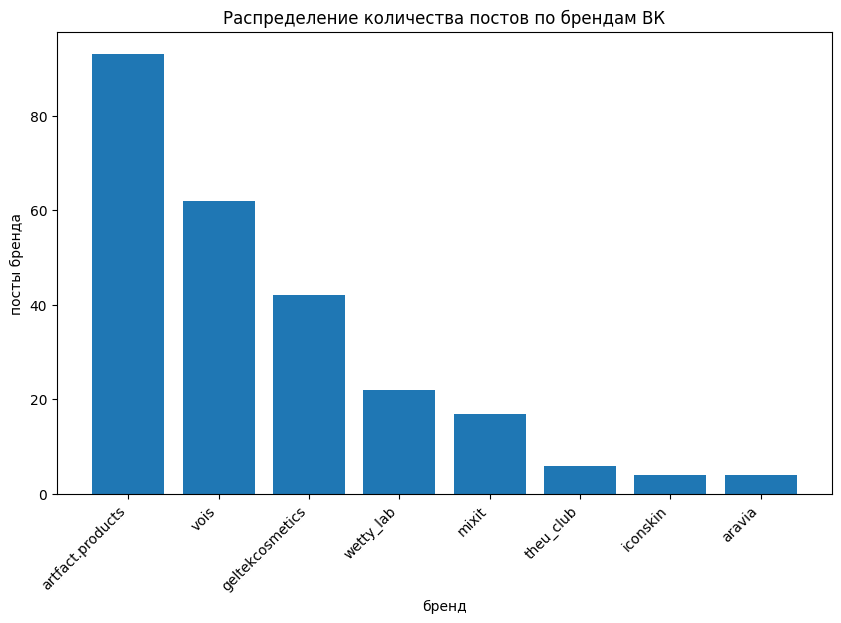

In [81]:
figsize(10, 6)

brand_counts = data['brand'].value_counts()
plt.bar(brand_counts.index, brand_counts.values)
plt.xticks(rotation = 45, ha = 'right')

plt.xlabel('бренд')
plt.ylabel('посты бренда')
plt.title('Распределение количества постов по брендам ВК')

artfact.products публикует больше всех, vois и geltekcosmetics тоже активны. beautybomb, iconskin, aravia почти не постят про wb хотя у aravia при этом огромные просмотры, значит один-два поста собрали весь охват

Text(0.5, 1.0, 'Сколько разных товаров WB упоминает каждый бренд')

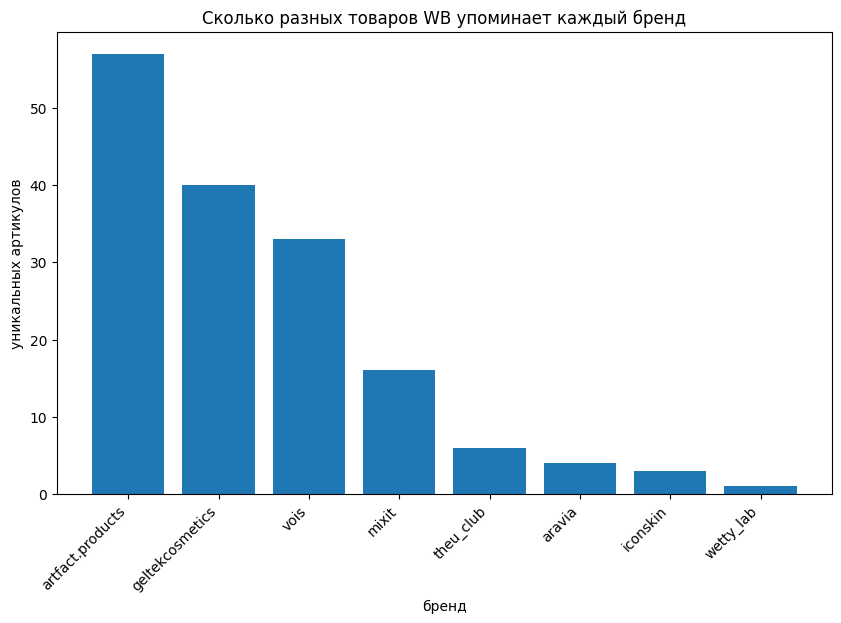

In [82]:
articles_per_brand = data.groupby('brand')['article'].nunique().sort_values(ascending=False)

figsize(10, 6)
plt.bar(articles_per_brand.index, articles_per_brand.values)
plt.xticks(rotation = 45, ha = 'right')
plt.xlabel('бренд')
plt.ylabel('уникальных артикулов')
plt.title('Сколько разных товаров WB упоминает каждый бренд')

сравнивая два графика видим что распределение постов и уникальных артикулов по брендам в целом совпадает — artfact.products лидер и там и там, geltekcosmetics и vois тоже в топе. но есть интересные расхождения: wetty_lab на 4 месте по количеству постов (22 поста) но на последнем по уникальным артикулам (всего 1), значит бренд постоянно пушит один и тот же товар. обратная ситуация у mixit — 17 постов и 16 артикулов, почти каждый пост про новый продукт. это показывает разные стратегии продвижения: wetty_lab бьёт в одну точку надеясь разогнать конкретный товар, а artfact.products и mixit развивают широкую витрину. для wb это значит что мерить эффективность брендов просто по числу постов нельзя, нужно смотреть еще и на разнообразие ассортимента в контенте

In [83]:
brand_stats = data.groupby('brand')[['likes_count', 'comments_count', 'reposts_count', 'views_count']].mean().round(1)
brand_stats = brand_stats.sort_values('likes_count', ascending = False)
brand_stats

,likes_count,comments_count,reposts_count,views_count
brand,,,,
mixit,236.6,27.8,4.8,6497.6
aravia,110.2,3.5,9.2,42919.8
iconskin,105.0,1.2,1.8,2077.5
artfact.products,50.0,1.5,1.6,1612.1
geltekcosmetics,37.5,1.7,1.8,2587.7
theu_club,8.5,0.8,0.0,706.0
vois,8.3,0.2,1.6,4499.0
wetty_lab,0.2,0.0,0.0,21.1


mixit лидирует по среднему числу лайков на пост (236) хотя по сумме был вторым, тк постов меньше а лайков много. aravia при 88 средних лайках имеет 34к средних просмотров на пост это аномалия, возможно реклама или виральный пост. vois средние лайки 8 при 4.5к просмотров значит аудитория пассивная

видим, что разные бренды по разному вкладываются в промоутирование своих продуктов в ВК, наша цель как раз изучить как это влияет на удовлетворенность пользователей продуктом по вб карточке: ожидаем, что 
1.охват не равно вовлеченность тк у vois и aravia огромные просмотры но мало лайков, скорее всего это закупка рекламы или посты попали в рекомендации но аудитория не заинтересована в продукте
2.mixit и artfact.products имеют лояльную аудиторию тк у них высокая вовлеченность(лайки/просмотры), значит подписчики целевые и реально интересуются брендом
3.частота постинга не коррелирует с успехом тк artfact постит больше всех, но mixit собирает больше лайков на пост, качество контента важнее количества
4.видим что aravia это аномалия, имеющая мало постов но гигантские просмотры, скорее всего один пост выстрелил или может реально хороший продукт рекламировали или акцию, нужно посмотреть конкретные посты

Text(0.5, 1.0, 'Коэффициент вовлечённости по брендам ВК')

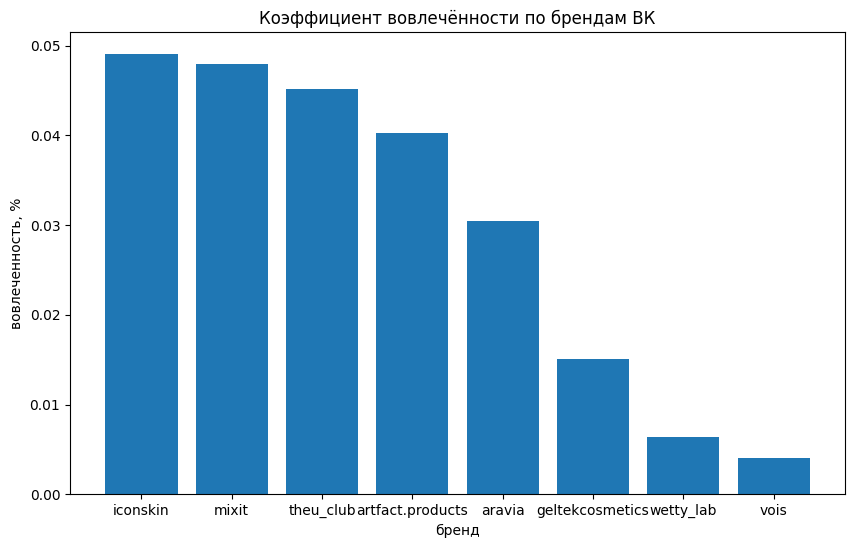

In [84]:
data['engagement'] = data['likes_count'] / data['views_count'].replace(0, np.nan)
er_by_brand = data.groupby('brand')['engagement'].mean().sort_values(ascending=False)

figsize(10, 6)
plt.bar(er_by_brand.index, er_by_brand.values)
plt.xlabel('бренд')
plt.ylabel('вовлеченность, %')
plt.title('Коэффициент вовлечённости по брендам ВК')

iconskin и mixit лидеры по вовлеченности почти 0.05%, хотя по абсолютным числам они в середине. vois у которого были максимальные просмотры оказался на последнем месте, значит эта аудитория просто скроллит ленту и не реагирует. подтверждает гипотезу что охват не равно вовлеченность

In [85]:
aravia_posts = data[data['brand'] == 'aravia'].sort_values('views_count', ascending=False)
aravia_posts[['date', 'text', 'likes_count', 'views_count', 'article']].head()

,date,text,likes_count,views_count,article
67,2026-03-13 11:00:00,"Увлажняющий крем – база любого ухода \n \nСобрали для вас ТОП увлажняющих продуктов, которые особенно подойдут для ежедневного применения весной \n \n· Крем с церамидами и мочевиной – когда кожа шелушится, чувствует стянутость и нуждается в питании \nПодробнее на сайте [#alias|vk.cc/cVvePw|https://vk.cc/cVvePw] | WB [#alias|vk.cc/cVp7bA|https://vk.cc/cVp7bA] | Ozon [#alias|vk.cc/cVp7hg|https://vk.cc/cVp7hg] \n \n· Защитный липо-крем с маслом норки – когда необходим мгновенный результат \nПодробнее на сайте [#alias|vk.cc/cVvfcf|https://vk.cc/cVvfcf] | WB [#alias|vk.cc/cVp7oy|https://vk.cc/cVp7oy] | Ozon [#alias|vk.cc/cVp7tr|https://vk.cc/cVp7tr]\n \n· Крем для лица интенсивно увлажняющий – когда необходимо укрепление защитного барьера кожи \nПодробнее на сайте[#alias|vk.cc/cVvfiU|https://vk.cc/cVvfiU] | WB [#alias|vk.cc/cVp7AE|https://vk.cc/cVp7AE] | Ozon [#alias|vk.cc/cVp7ET|https://vk.cc/cVp7ET] \n \n· Крем для лица с мочевиной и муцином улитки – когда необходимо восстановить барьерную функцию кожи \nПодробнее на сайте [#alias|vk.cc/cVvfnR|https://vk.cc/cVvfnR] | WB [#alias|vk.cc/cVp7Nb|https://vk.cc/cVp7Nb] | Ozon [#alias|vk.cc/cVp7RR|https://vk.cc/cVp7RR]\n \nНапишите в комментариях свой любимый увлажняющий крем",179,164538,51924124.0
66,2026-03-17 13:32:24,"Весна – не повод откладывать ретинол до осени \n \nРетинол не «запрещен» весной и летом. Он не делает кожу тоньше и не вызывает пигментацию сам по себе \nПроблемы возникают тогда, когда нет SPF, есть агрессивные сочетания и нарушен барьер кожи \n \nЕсли сомневаетесь, оставлять ли ретинол в уходе – ориентируйтесь на состояние кожи, а не на календарь \n \n— Обновляющий гель для умывания: САЙТ [#alias|vk.cc/cVxsQk|https://vk.cc/cVxsQk] · WB [#alias|vk.cc/cVxsS4|https://vk.cc/cVxsS4] · OZON [#alias|vk.cc/cVxtOM|https://vk.cc/cVxtOM] \n— Тонер для лица: САЙТ [#alias|vk.cc/cVxwHI|https://vk.cc/cVxwHI] · WB [#alias|vk.cc/cVxwNZ|https://vk.cc/cVxwNZ] · OZON [#alias|vk.cc/cVxwX6|https://vk.cc/cVxwX6] \n— Крем для лица 0.7: САЙТ [#alias|vk.cc/cVxx8c|https://vk.cc/cVxx8c] · WB [#alias|vk.cc/cVxxcT|https://vk.cc/cVxxcT] · OZON [#alias|vk.cc/cVxxhb|https://vk.cc/cVxxhb] \n— Крем для лица 1.0: САЙТ [#alias|vk.cc/cVxxlX|https://vk.cc/cVxxlX] · WB [#alias|vk.cc/cVxxqf|https://vk.cc/cVxxqf] · OZON [#alias|vk.cc/cVxxvm|https://vk.cc/cVxxvm] \n— Крем для кожи вокруг глаз: САЙТ [#alias|vk.cc/cVxxAP|https://vk.cc/cVxxAP] · WB [#alias|vk.cc/cVxxHg|https://vk.cc/cVxxHg] · OZON [#alias|vk.cc/cVxxO3|https://vk.cc/cVxxO3] \n— Защитный крем-праймер для лица: : САЙТ [#alias|vk.cc/cVxxTX|https://vk.cc/cVxxTX] · WB [#alias|vk.cc/cVxxYZ|https://vk.cc/cVxxYZ] · OZON [#alias|vk.cc/cVxy41|https://vk.cc/cVxy41]\n \nВы используете ретинол круглый год или делаете паузу?",143,5255,378918708.0
68,2025-12-19 14:59:25,"Рассказываем, как зимой сохранить здоровье и блеск волос 🤍 \n \nИспользуйте средства, которые повышают защитные функции, глубоко увлажняют и предотвращают обезвоживание и сечение, а также устраняют ломкость и тусклость. \n \nШампунь увлажняющий для восстановления сухих, обезвоженных волос Hydra Pure \n• на сайте [#alias|vk.cc/cSxXFW|https://vk.cc/cSxXFW] \n• на WB [#alias|vk.cc/cSxXJQ|https://vk.cc/cSxXJQ] \n• на OZON [#alias|vk.cc/cSxXOT|https://vk.cc/cSxXOT] \n \nМаска кератиновая для интенсивного питания и увлажнения волос Hydra Keratin SOS-Mask \n• на сайте [#alias|vk.cc/cSxXSz|https://vk.cc/cSxXSz] \n • на WB [#alias|vk.cc/cSxYdU|https://vk.cc/cSxYdU] \n • на OZON [#alias|vk.cc/cSxYhp|https://vk.cc/cSxYhp] \n \nКрем-уход восстанавливающий для глубокого увлажнения сухих и обезвоженных волос Hydra Gloss Cream \n • на сайте [#alias|vk.cc/cSxYlP|https://vk.cc/cSxYlP] \n • на WB [#alias|vk.cc/cSxYop|https://vk.cc/cSxYop] \n • на OZON [#alias|vk.cc/cSxYsu|https://vk.cc/cSxYsu] \n \nРасскажите, как вы защищаете волосы в зимний период?",119,1886,16064709.0
283,2024-01-15 10:50:58,"[id5461130|Ксения], здравствуйте!\nНа сайте раскупил

аномалия подтверждается, один пост от 2026 03 13 собрал 164к просмотров и всего 179 лайков это огромная площадь покрытия при крошечной вовлеченности, значит пост действительно попал в рекомендации или был платным размещением. второй пост 2026 03 17 тоже виральный 378 тысяч просмотров при 143 лайках. остальные посты aravia почти не видны, вывод весь охват бренда держится буквально на двух постах

In [86]:
top_viral = data.sort_values('views_count', ascending=False).head(10)
top_viral[['brand', 'date', 'likes_count', 'views_count']]

,brand,date,likes_count,views_count
100,vois,2025-09-11 12:29:40,69,164750
67,aravia,2026-03-13 11:00:00,179,164538
97,vois,2025-10-21 16:39:44,33,20941
249,mixit,2026-02-04 05:29:00,326,11670
255,mixit,2026-01-22 06:38:00,232,11205
251,mixit,2026-01-30 05:26:00,260,9723
22,geltekcosmetics,2025-12-18 14:26:30,141,9140
240,mixit,2026-03-28 08:45:18,164,9044
241,mixit,2026-03-12 12:48:21,179,9031
288,vois,2025-11-22 08:59:00,9,8874


видим, что почти весь топ занимают vois, mixit и aravia, причем посты mixit в топе имеют адекватное соотношение лайков к просмотрам (200-300 лайков на 9-11к просмотров), а vois и aravia выбиваются огромными просмотрами при низких лайках. geltekcosmetics тоже попал в топ один раз

-0.2828546673328158


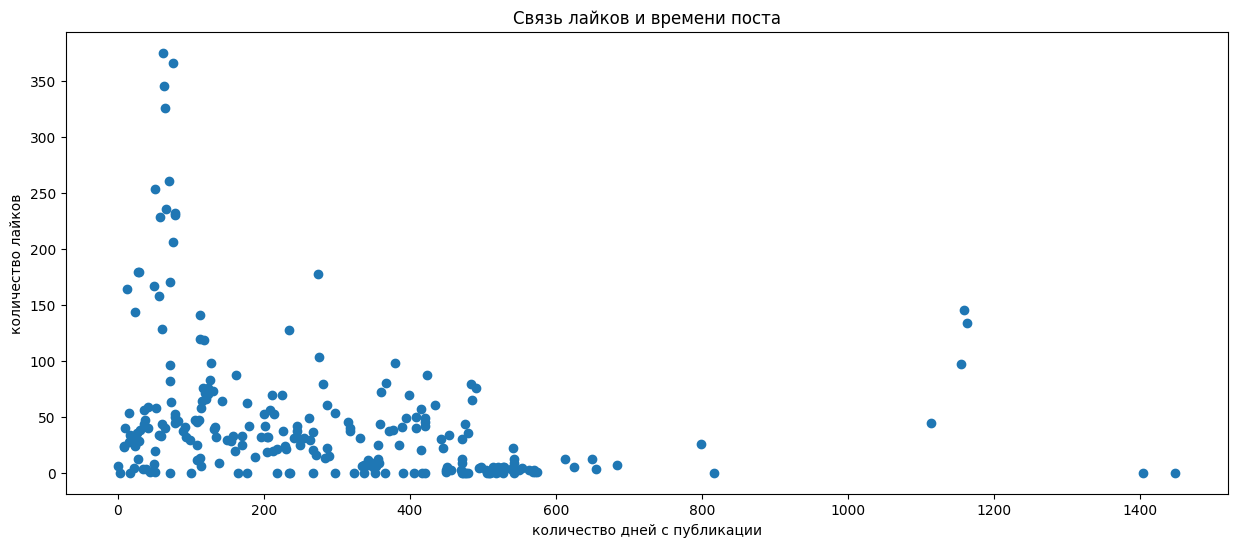

In [87]:
data['days_since_post'] = (pd.Timestamp.now() - data['date']).dt.days
figsize(15, 6)
plt.scatter(data['days_since_post'], data['likes_count'])

r = np.corrcoef(data['days_since_post'], data['likes_count'])[0][1]

plt.xlabel('количество дней с публикации')
plt.ylabel('количество лайков')
plt.title('Связь лайков и времени поста')
print(r)

слабая отрицательная корреляция, то есть старые посты в среднем имеют меньше лайков но связь не сильная. видим что основная масса лайков на постах до 500 дней, после этого лайков мало. логично тк свежий контент активнее показывается в ленте

0.9293156298933587


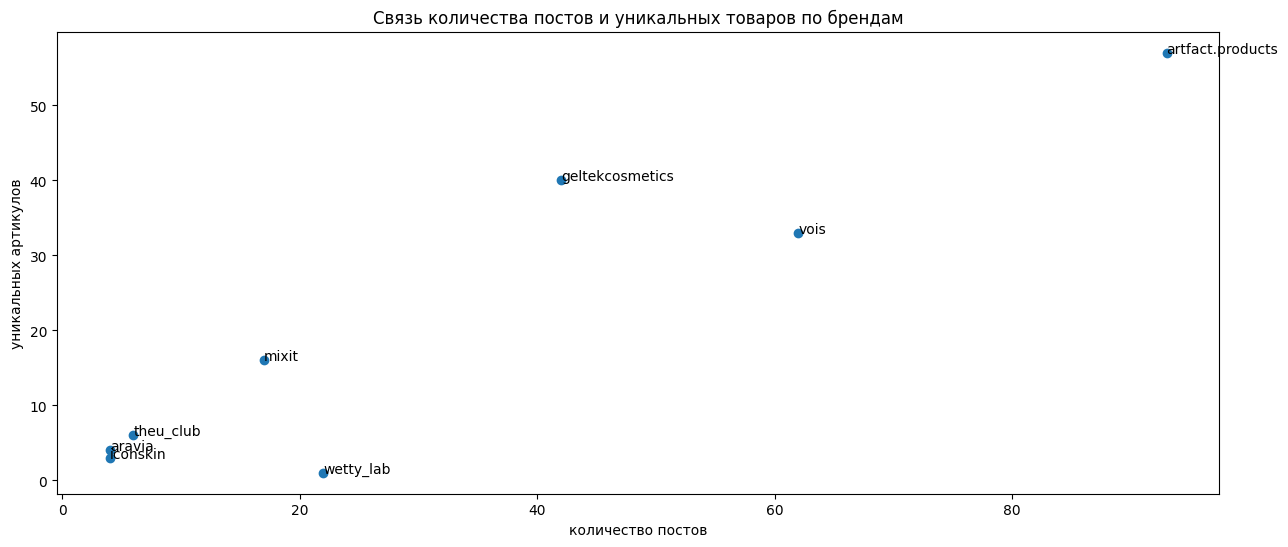

In [100]:
articles_per_brand = data.groupby('brand')['article'].nunique()
posts_per_brand = data.groupby('brand').size()

figsize(15, 6)

plt.scatter(posts_per_brand, articles_per_brand)

for brand in posts_per_brand.index:
    plt.annotate(brand, (posts_per_brand[brand], articles_per_brand[brand]))

r = np.corrcoef(posts_per_brand, articles_per_brand)[0][1]

plt.xlabel('количество постов')
plt.ylabel('уникальных артикулов')
plt.title('Связь количества постов и уникальных товаров по брендам')
print(r)

очень сильная положительная корреляция, чем больше бренд постит тем больше разных товаров упоминает. artfact.products с 90 постами упоминает 57 уникальных артикулов, geltekcosmetics 45 постов на 42 артикула. интересно что wetty_lab выбивается из тренда 25 постов но всего 1 уникальный артикул, значит они постоянно продвигают один и тот же товар

посмотрим на стратегии которые выьирают бренды, чтобы потом по данным с карточек вб оценить какая успешнее 

In [91]:
strategy = pd.DataFrame({'posts': posts_per_brand, 'unique_articles': articles_per_brand,})
strategy['articles_per_post'] = (strategy['unique_articles'] / strategy['posts']).round(2)
strategy = strategy.sort_values('articles_per_post', ascending=False)
strategy

,posts,unique_articles,articles_per_post
brand,,,
aravia,4,4,1.00
theu_club,6,6,1.00
geltekcosmetics,42,40,0.95
mixit,17,16,0.94
iconskin,4,3,0.75
artfact.products,93,57,0.61
vois,62,33,0.53
wetty_lab,22,1,0.05


видим три четких группы брендов по стратегии продвижения. первая группа aravia, beautybomb, theu_club, mixit, geltekcosmetics — articles_per_post почти равен 1, это значит каждый пост про новый товар, классическая витринная стратегия где бренд показывает весь ассортимент
вторая группа artfact.products и vois — показатель 0.5-0.6, то есть половина постов повторяет уже упомянутые товары, видимо эти бренды дополнительно подогревают интерес к хитам продаж
третья группа wetty_lab с показателем 0.05 — это полная противоположность, 22 поста и всего 1 уникальный артикул, бренд буквально долбит один товар во всех постах. такая стратегия работает только если этот один товар реально топовый, иначе это просто спам. для wb это означает что бренды с высоким articles_per_post ближе к маркетплейс-логике (показать весь каталог), а wetty_lab ведет себя скорее как моно-продуктовый бренд

In [101]:
article_features = data.groupby('article').agg(
    n_mentions=('text', 'count'),
    n_brands=('brand', 'nunique'),
    total_likes=('likes_count', 'sum'),
    total_views=('views_count', 'sum'),
    total_comments=('comments_count', 'sum'),
    total_reposts=('reposts_count', 'sum'),
    avg_likes=('likes_count', 'mean'),
    avg_views=('views_count', 'mean'),
    first_mention=('date', 'min'),
    last_mention=('date', 'max'),
).round(2)

article_features['promo_duration_days'] = (article_features['last_mention'] - article_features['first_mention']).dt.days
article_features = article_features.sort_values('n_mentions', ascending=False)
article_features.head(15)
article_features.to_csv('groupproject_2/vk_eda/article_features.csv', encoding='utf-8')

Text(0.5, 1.0, 'Топ 15 самых упоминаемых артикулов WB в постах ВК')

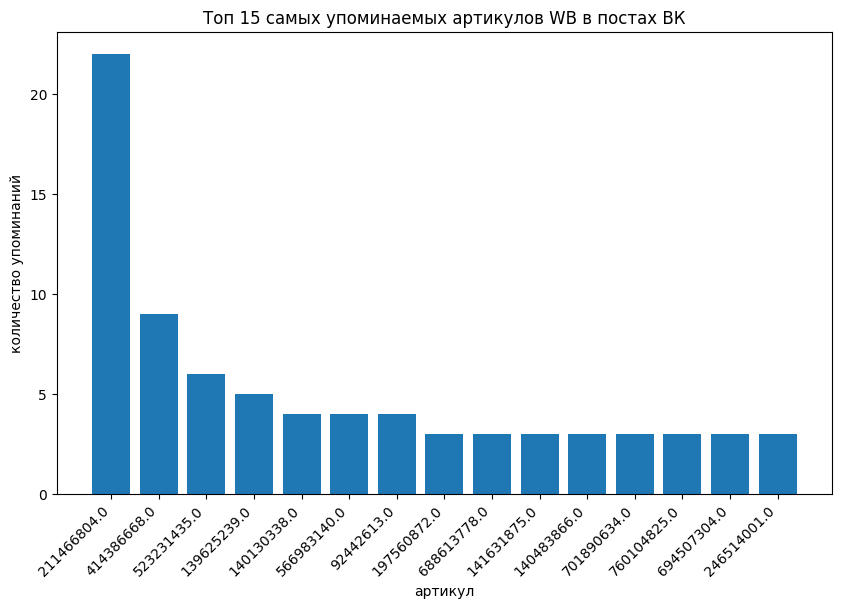

In [93]:
figsize(10, 6)
top15 = article_features.head(15)
plt.bar(top15.index.astype(str), top15['n_mentions'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('артикул')
plt.ylabel('количество упоминаний')
plt.title('Топ 15 самых упоминаемых артикулов WB в постах ВК')

от этих товаров и будем ожидать наивысшие показатели удовлетворенности среди клиентов вб

In [ ]:
wb = pd.read_csv('groupproject_2/wb_eda.csv')
af = pd.read_csv('groupproject_2/vk_eda/article_features.csv')

wb['article'] = wb['id'].astype(int)
af['article'] = af['article'].astype(int)

wb_ids = set(wb['article'])
af_ids = set(af['article'])

matched = af[af['article'].isin(wb_ids)].copy()
matched = matched.merge(wb[['article', 'brand', 'name', 'rating', 'reviews']], on='article', how='left')
matched['status'] = 'matched'

only_vk = af[~af['article'].isin(wb_ids)].copy()
only_vk['brand'] = ''
only_vk['name'] = ''
only_vk['rating'] = None
only_vk['reviews'] = None
only_vk['status'] = 'only_vk'

result = pd.concat([matched, only_vk], ignore_index=True)
result = result[['article', 'status', 'brand', 'name', 'rating', 'reviews',
                 'n_mentions', 'total_likes', 'total_views', 'first_mention', 'last_mention']]

result.to_csv('groupproject_2/vk_eda/articles_match_status.csv', index=False, encoding='utf-8')

result.head(10)

/var/folders/r_/2wkkzvbn699_blmtldcwl55h0000gn/T/ipykernel_60574/1579724862.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat([matched, only_vk], ignore_index=True)


,article,status,brand,name,rating,reviews,n_mentions,total_likes,total_views,first_mention,last_mention
0,211466804,matched,wetty_lab,Крем для тела увлажняющий питательный для ухода,4.8,229.0,22,5,464,2024-12-18 15:29:51,2026-04-06 18:53:42
1,414386668,matched,art&fact,"Энзимная пудра для умывания с витамином C, 65 г",4.8,9933.0,9,360,8060,2025-07-29 10:35:59,2026-01-29 12:35:48
2,414386668,matched,art&fact,"Энзимная пудра для умывания с витамином C, 65 г",4.8,9935.0,9,360,8060,2025-07-29 10:35:59,2026-01-29 12:35:48
3,139625239,matched,vois,Пенка для умывания лица увлажняющая очищающая 150 мл,4.8,86492.0,5,18,4693,2024-06-24 12:00:02,2025-04-27 07:40:00
4,139625239,matched,vois,Пенка для умывания лица увлажняющая очищающая 150 мл,4.8,86492.0,5,18,4693,2024-06-24 12:00:02,2025-04-27 07:40:00
5,140130338,matched,vois,Масло для массажа тела увлажняющее антицеллюлитное 500мл,4.9,50716.0,4,33,7146,2024-09-13 09:00:01,2025-08-03 07:46:00
6,566983140,matched,art&fact,Набор масок для лица очищение и увлажнение,4.9,127.0,4,185,3474,2026-02-05 13:25:00,2026-03-05 13:28:46
7,566983140,matched,art&fact,Набор масок для лица очищение и увлажнение,4.8,131.0,4,185,3474,2026-02-05 13:25:00,2026-03-05 13:28:46
8,92442613,matched,vois,Маска для лица тканевая набор 30 шт,4.9,248668.0,4,41,6942,2024-09-17 09:00:01,2025-09-26 11:30:00
9,92442613,matched,vois,Маска для лица тканевая набор 30 шт,4.9,248668.0,4,41,6942,2024-09-17 09:00:01,2025-09-26 11:30:00
